In [1]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

  Activating project at `~/OneDrive_xwc@zju.edu.cn/optimal-control/my-notes/code/with-notes/lec3`


In [2]:
using LinearAlgebra
using ForwardDiff
using PyPlot
using LaTeXStrings
using JupyterFormatter
enable_autoformat()
PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "Times New Roman")
PyPlot.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

In [3]:
function pendulum_dynamics(x)
    l = 1.0
    g = 9.81
    theta = x[1]
    dot_theta = x[2]
    ddot_theta = -(g / l) * sin(theta)
    return [dot_theta; ddot_theta]
end

pendulum_dynamics (generic function with 1 method)

In [4]:
function backward_euler_step_fixed_point(fun, x0, h)
    xn = x0
    e = [norm(x0 + h .* fun(xn) - xn)]
    while e[end] > 1e-8
        xn = x0 + h .* fun(xn)
        e = [e; norm(x0 + h .* fun(xn) - xn)]
    end
    return xn, e
end

backward_euler_step_fixed_point (generic function with 1 method)

In [5]:
function backward_euler_step_newton(fun, x0, h)
    xn = x0
    r = x -> x0 + h .* fun(x) - x
    e = [norm(r(xn))]
    while e[end] > 1e-8
        prpx = ForwardDiff.jacobian(x -> r(x), xn)
        xn = xn - prpx \ r(xn)
        e = [e; norm(r(xn))]
    end
    return xn, e
end

backward_euler_step_newton (generic function with 1 method)

In [6]:
function backward_euler_fixed_point(fun, x0, Tf, h)
    t = Array(range(0, Tf, step = h))
    x_hist = zeros(length(x0), length(t))
    x_hist[:, 1] .= x0
    for k = 1:length(t)-1
        x_hist[:, k+1], e = backward_euler_step_fixed_point(fun, x_hist[:, k], h)
    end
    return x_hist, t
end

backward_euler_fixed_point (generic function with 1 method)

In [7]:
function backward_euler_newton(fun, x0, Tf, h)
    t = Array(range(0, Tf, step = h))
    x_hist = zeros(length(x0), length(t))
    x_hist[:, 1] .= x0
    for k = 1:length(t)-1
        x_hist[:, k+1], e = backward_euler_step_newton(fun, x_hist[:, k], h)
    end
    return x_hist, t
end

backward_euler_newton (generic function with 1 method)

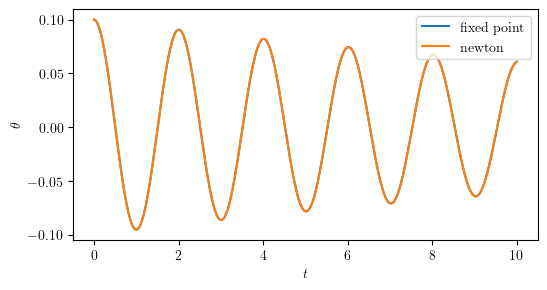

In [24]:
x0 = [0.1; 0]
x_hist1, t_hist1 = backward_euler_fixed_point(pendulum_dynamics, x0, 10, 0.01);
x_hist2, t_hist2 = backward_euler_newton(pendulum_dynamics, x0, 10, 0.01);
fig = figure(figsize = (6, 3))
plot(t_hist1, x_hist1[1, :], label = "fixed point");
plot(t_hist2, x_hist2[1, :], label = "newton");
xlabel(L"t");
ylabel(L"\theta");
legend()
savefig("1.pdf", bbox_inches = "tight")

In [38]:
max(abs.(x_hist1 - x_hist2)...)

7.3007510554383426e-6

In [14]:
xn, e1 = backward_euler_step_fixed_point(pendulum_dynamics, x0, 0.1)
e1

14-element Vector{Float64}:
 0.09793658173053843
 0.009793658173053846
 0.009564124766684667
 0.0009564124766684723
 0.0009343853483241293
 9.343853483241571e-5
 9.128296581455142e-5
 9.128296581450979e-6
 8.917746787032166e-6
 8.917746786990532e-7
 8.712050176828967e-7
 8.712050177106523e-8
 8.511098474606182e-8
 8.511098478769519e-9

In [15]:
xn, e2 = backward_euler_step_newton(pendulum_dynamics, x0, 0.1)
e2

3-element Vector{Float64}:
 0.09793658173053843
 3.7830087232931797e-6
 5.2874553670659e-15

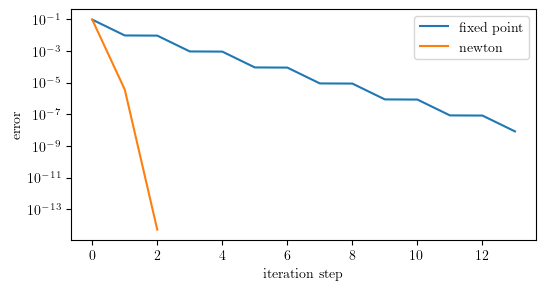

In [27]:
fig = figure(figsize = (6, 3))
semilogy(e1, label = "fixed point")
semilogy(e2, label = "newton")
xlabel("iteration step");
ylabel("error");
legend()
savefig("6.pdf", bbox_inches = "tight")